<a href="https://colab.research.google.com/github/Utkarsh-3108/Appropriate-Model-Detection-in-Outpatient-Healthcare-An-AI-and-ML-Based-Approach-for-Best-Treatment./blob/main/Aligning_Prescription_Intensity_with_Symptom_severity_in_OPD_Records_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)


In [3]:
df = pd.read_csv('patient_dataset_4000_structured.csv')
df.columns   = [c.strip() for c in df.columns]
df['age']    = pd.to_numeric(df['age'], errors='coerce').fillna(30).astype(int)
df['billAmount'] = pd.to_numeric(df['billAmount'], errors='coerce')
df.dropna(subset=['complaint', 'prescription', 'disease'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Dataset loaded: {len(df)} records | {df['disease'].nunique()} diseases")

Dataset loaded: 4000 records | 10 diseases


In [4]:
# ── SECTION 3: SYMPTOM SEVERITY SCORING (SSS) ─────────────────
# Each symptom is assigned a clinical weight:
#   3 = High severity  |  2 = Moderate  |  1 = Mild
SYMPTOM_SEVERITY = {
    'chest pain': 3, 'shortness of breath': 3, 'cough with phlegm': 3,
    'high fever': 3, 'severe headache': 3, 'prolonged fever': 3,
    'dehydration': 3, 'eye pain': 3, 'burning urination': 3,
    'fever': 2, 'headache': 2, 'joint pain': 2, 'abdominal pain': 2,
    'muscle pain': 2, 'diarrhea': 2, 'nausea': 2, 'dizziness': 2,
    'blurred vision': 2, 'fatigue': 2, 'chills': 2, 'sweating': 2,
    'skin rash': 2, 'body pain': 2, 'stomach cramps': 2, 'cloudy urine': 2,
    'frequent urination': 2, 'loss of appetite': 2, 'weakness': 2,
    'lower abdominal pain': 2, 'light sensitivity': 2, 'sound sensitivity': 2,
    'excessive thirst': 2, 'slow healing': 2, 'tingling': 2, 'vomiting': 2,
    'coughing': 1, 'sneezing': 1, 'runny nose': 1, 'sore throat': 1, 'aura': 1,
}

def compute_severity(complaint_text):
    symptoms = [s.strip().lower() for s in str(complaint_text).split(',') if s.strip()]
    score    = sum(SYMPTOM_SEVERITY.get(s, 1) for s in symptoms)
    return score, len(symptoms)

# ── SECTION 4: PRESCRIPTION INTENSITY INDEX (PII) ─────────────
# Each medicine is assigned a pharmacological weight:
#   3 = High intensity (antibiotics/antiparasitics)
#   2 = Moderate (analgesics, antidiabetics, antihypertensives)
#   1 = Low (ORS, supportive care, lifestyle)
MEDICINE_INTENSITY = {
    'ciprofloxacin': 3, 'azithromycin': 3, 'amoxicillin': 3,
    'chloroquine': 3, 'primaquine': 3, 'nitrofurantoin': 3,
    'trimethoprim': 3, 'metronidazole': 3, 'sumatriptan': 3,
    'ibuprofen': 2, 'levocetirizine': 2, 'ondansetron': 2,
    'glipizide': 2, 'metformin': 2, 'amlodipine': 2,
    'losartan': 2, 'aspirin': 2, 'dextromethorphan': 2,
    'zinc': 2, 'paracetamol 1000': 2, 'paracetamol 650': 2, 'iv fluids': 2,
    'paracetamol 500': 1, 'ors': 1, 'steam inhalation': 1,
    'cranberry': 1, 'plenty of fluids': 1, 'rest in dark room': 1,
    'papaya leaf': 1, 'diet control': 1, 'exercise regimen': 1,
    'lifestyle modification': 1, 'cough syrup': 1,
}

def compute_intensity(prescription_text):
    text = str(prescription_text).lower()
    match = re.search(r'medications:\s*(.*?)(?:\|\s*instructions:|$)', text, re.IGNORECASE)
    meds  = [m.strip() for m in (match.group(1) if match else text).split('|') if m.strip()]
    score = 0
    for med in meds:
        for key, weight in MEDICINE_INTENSITY.items():
            if key in med:
                score += weight
                break
        else:
            score += 1
    return score, len(meds)

In [5]:
# Apply scoring to dataset
sev_results   = df['complaint'].apply(compute_severity)
inten_results = df['prescription'].apply(compute_intensity)

df['severity_score']  = sev_results.apply(lambda x: x[0])
df['num_symptoms']    = sev_results.apply(lambda x: x[1])
df['intensity_score'] = inten_results.apply(lambda x: x[0])
df['num_medicines']   = inten_results.apply(lambda x: x[1])

In [6]:
# ── SECTION 5: ALIGNMENT RATIO + LABEL ASSIGNMENT ─────────────
df['align_ratio'] = df['intensity_score'] / (df['severity_score'] + 0.001)

# Compute disease-specific baseline (mean ± std)
norms            = df.groupby('disease')['align_ratio'].agg(
                       norm_mean='mean', norm_std='std').reset_index()
norms['norm_std']= norms['norm_std'].clip(lower=0.05)
df               = df.merge(norms, on='disease', how='left')

# Z-score threshold ±0.8 for label assignment
def assign_label(row):
    z = (row['align_ratio'] - row['norm_mean']) / row['norm_std']
    if z > 0.8:    return 'Over-treated'
    elif z < -0.8: return 'Under-treated'
    else:          return 'Appropriate'

df['alignment'] = df.apply(assign_label, axis=1)
print(f"\nAlignment Distribution:\n{df['alignment'].value_counts()}")


Alignment Distribution:
alignment
Appropriate      2275
Under-treated     910
Over-treated      815
Name: count, dtype: int64


In [8]:
# ── SECTION 6: FEATURE ENGINEERING ────────────────────────────
le_disease        = LabelEncoder()
df['disease_enc'] = le_disease.fit_transform(df['disease'])
df['age_group']   = pd.cut(df['age'], bins=[0,12,18,40,60,100],
                            labels=[0,1,2,3,4]).astype(int)
df['bill_per_med']= df['billAmount'] / (df['num_medicines'] + 1)

FEATURES  = ['num_symptoms','num_medicines','age','age_group',
             'disease_enc','bill_per_med','severity_score','intensity_score']
X         = df[FEATURES].fillna(0)
le_label  = LabelEncoder()
y         = le_label.fit_transform(df['alignment'])
classes   = le_label.classes_

In [9]:
# ── SECTION 7: TRAIN / TEST SPLIT ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [10]:
model_list1 = [
    ('Logistic Regression', LogisticRegression(max_iter=500, C=0.5, random_state=42),          True),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, max_depth=8,
                                min_samples_leaf=5, random_state=42),                           False),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                learning_rate=0.1, subsample=0.8,
                                min_samples_leaf=10, random_state=42),                          False),
    ('Linear SVM',          LinearSVC(max_iter=2000, C=0.5, random_state=42),                  True),
]

results    = {}
best_preds = None
for name, model, use_scaled in model_list1:
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='weighted')
    cv    = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')
    results[name] = {'acc': round(acc*100,2), 'f1': round(f1*100,2)}
    print(f"\n{name} → Accuracy: {acc*100:.2f}%  F1: {f1*100:.2f}%  CV: {cv.mean()*100:.2f}%")
    print(classification_report(y_test, preds, target_names=classes, digits=3))
    if name == 'Gradient Boosting':
        best_preds = preds



Logistic Regression → Accuracy: 86.88%  F1: 86.87%  CV: 87.78%
               precision    recall  f1-score   support

  Appropriate      0.884     0.886     0.885       455
 Over-treated      0.853     0.853     0.853       163
Under-treated      0.845     0.841     0.843       182

     accuracy                          0.869       800
    macro avg      0.861     0.860     0.860       800
 weighted avg      0.869     0.869     0.869       800


Random Forest → Accuracy: 92.88%  F1: 92.85%  CV: 92.56%
               precision    recall  f1-score   support

  Appropriate      0.925     0.952     0.938       455
 Over-treated      0.943     0.920     0.932       163
Under-treated      0.925     0.879     0.901       182

     accuracy                          0.929       800
    macro avg      0.931     0.917     0.924       800
 weighted avg      0.929     0.929     0.929       800


Gradient Boosting → Accuracy: 98.88%  F1: 98.87%  CV: 98.31%
               precision    recall  f1-s

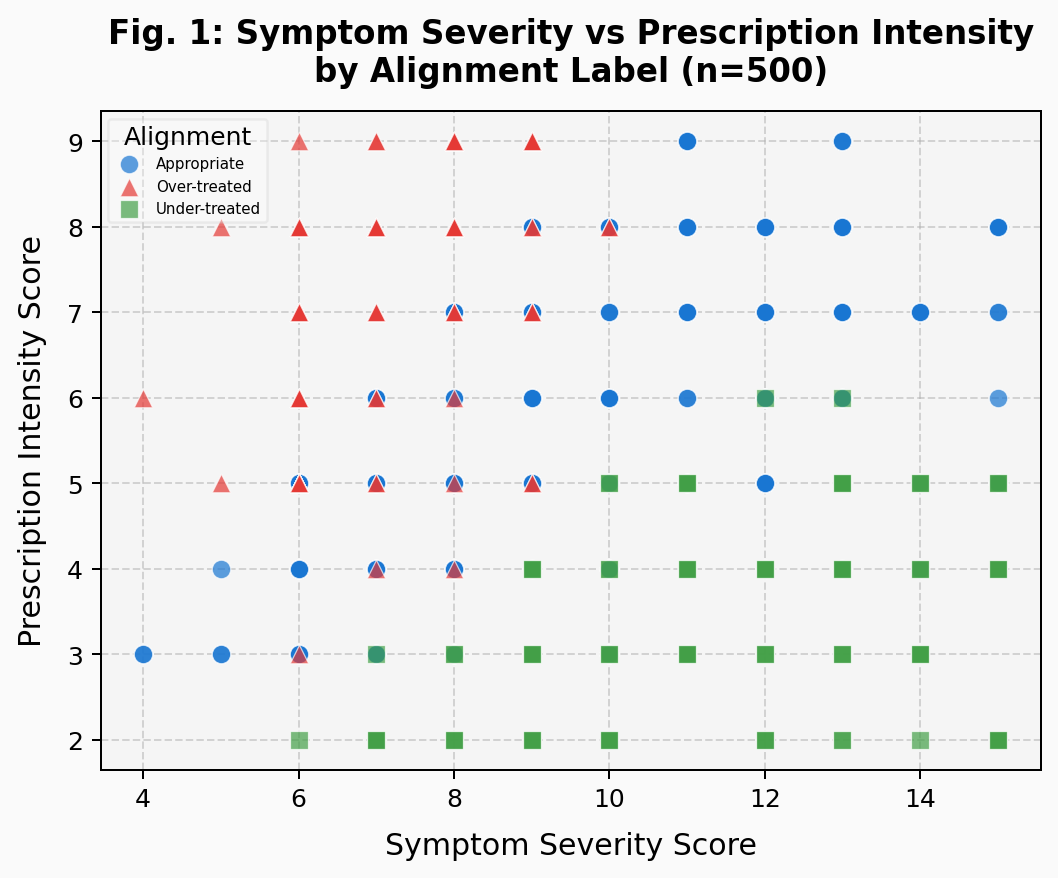

In [11]:
# FIGURE 1 — SCATTER PLOT
sample = df.sample(500, random_state=42)
clr_map = {'Appropriate':'#1976D2','Over-treated':'#E53935','Under-treated':'#43A047'}
mkr_map = {'Appropriate':'o','Over-treated':'^','Under-treated':'s'}
fig1, axi_1 = plt.subplots(figsize=(6,5))
fig1.patch.set_facecolor('#FAFAFA'); axi_1.set_facecolor('#F5F5F5')
for lbl in ['Appropriate','Over-treated','Under-treated']:
    sub = sample[sample['alignment']==lbl]
    axi_1.scatter(sub['severity_score'], sub['intensity_score'], c=clr_map[lbl], marker=mkr_map[lbl], alpha=0.70, s=55, edgecolors='white', linewidths=0.5, label=lbl, zorder=3)
axi_1.set_xlabel('Symptom Severity Score', fontsize=12, labelpad=8)
axi_1.set_ylabel('Prescription Intensity Score', fontsize=12, labelpad=8)
axi_1.set_title('Fig. 1: Symptom Severity vs Prescription Intensity\nby Alignment Label (n=500)', fontsize=13, fontweight='bold', pad=12)
axi_1.legend(title='Alignment', fontsize=6, framealpha=0.3, loc='upper left')
axi_1.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.savefig('figure1_scatter.png', dpi=180, bbox_inches='tight')
from IPython.display import Image
Image(filename='figure1_scatter.png')

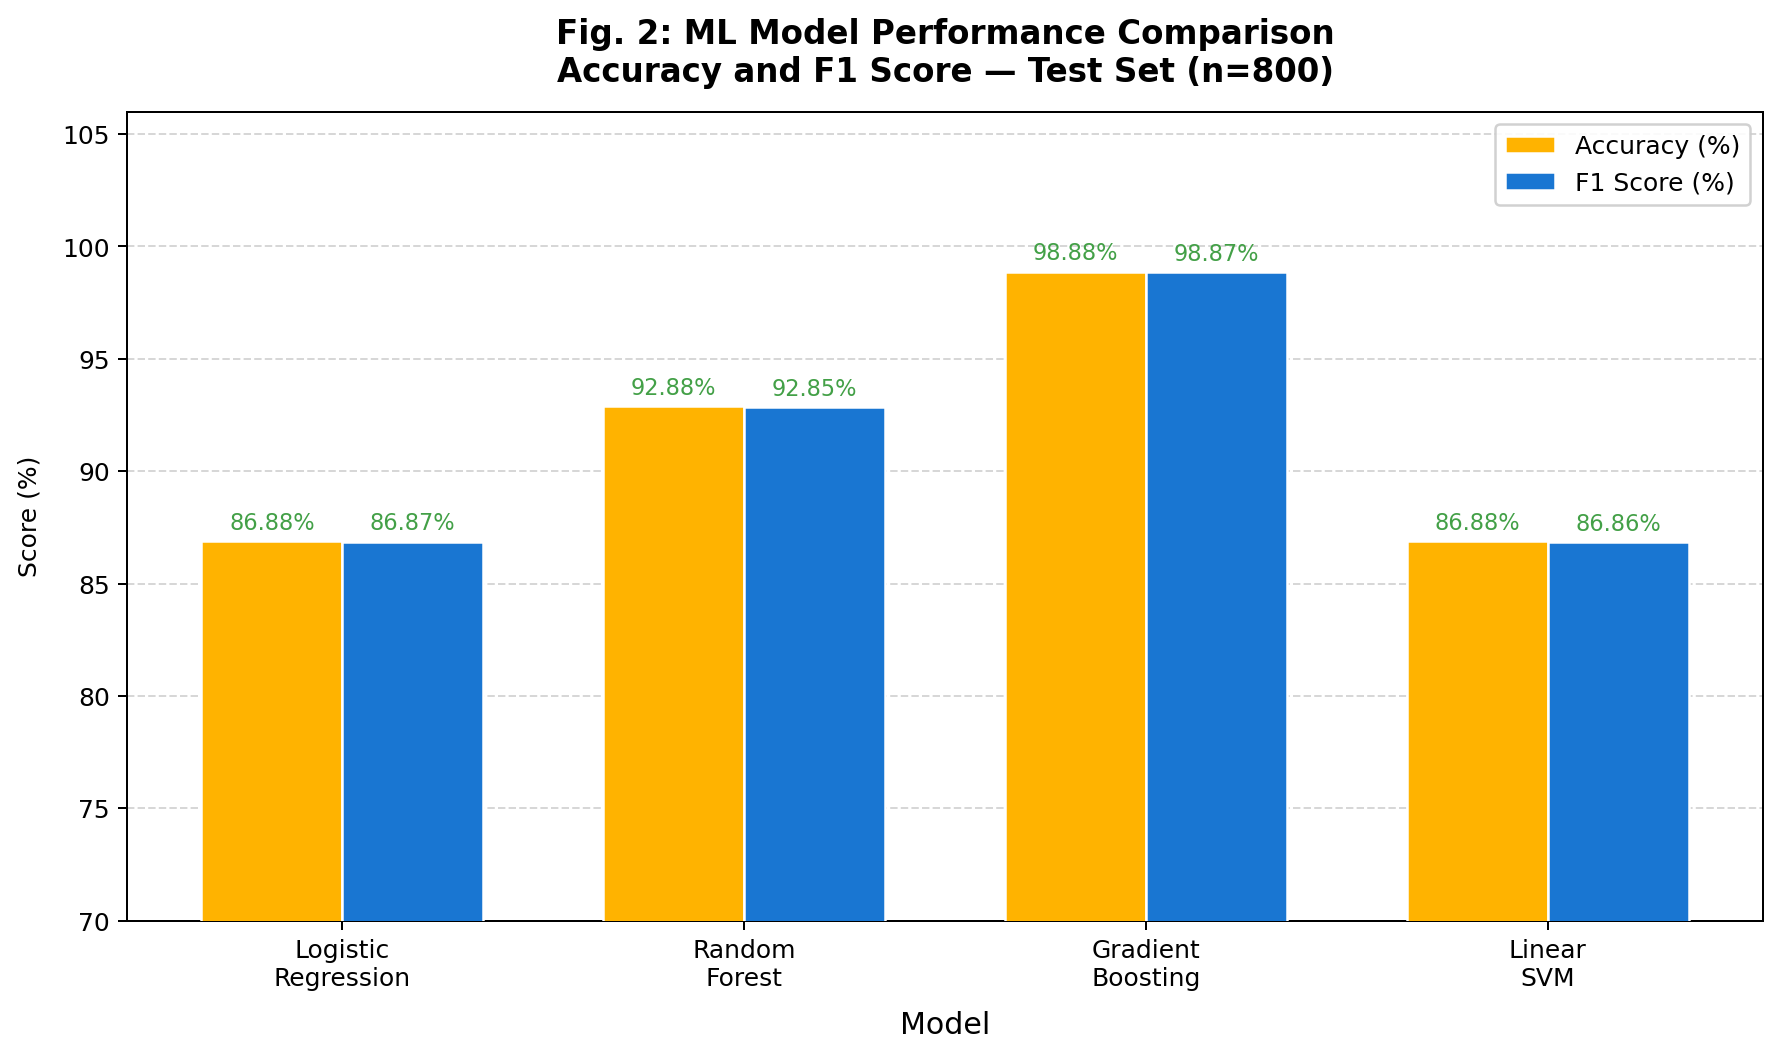

In [12]:
# FIGURE 2 — MODEL COMPARISON BAR CHART
names_plot = ['Logistic\nRegression','Random\nForest','Gradient\nBoosting','Linear\nSVM']
acc_vals = [results[n.replace('\n',' ')]['acc'] for n in names_plot]
f1_vals = [results[n.replace('\n',' ')]['f1'] for n in names_plot]
x = np.arange(len(names_plot)); w = 0.35
fig2, ax2 = plt.subplots(figsize=(10,6))
fig2.patch.set_facecolor('white'); ax2.set_facecolor('white')
b1 = ax2.bar(x-w/2, acc_vals, w, label='Accuracy (%)', color='#FFB300', edgecolor='white', zorder=3)
b2 = ax2.bar(x+w/2, f1_vals, w, label='F1 Score (%)', color='#1976D2', edgecolor='white', zorder=3)
for bar,col in zip(list(b1)+list(b2), ['#43A047']*4+['#43A047']*4):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9, color=col)
ax2.set_xlabel('Model', fontsize=12, labelpad=8)
ax2.set_ylabel('Score (%)', fontsize=10, labelpad=8)
ax2.set_title('Fig. 2: ML Model Performance Comparison\nAccuracy and F1 Score — Test Set (n=800)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xticks(x); ax2.set_xticklabels(names_plot, fontsize=10)
ax2.set_ylim(70,106); ax2.legend(fontsize=10, framealpha=0.9, loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.savefig('figure2_model_comparison.png', dpi=180, bbox_inches='tight')
from IPython.display import Image
Image(filename='/content/figure2_model_comparison.png')

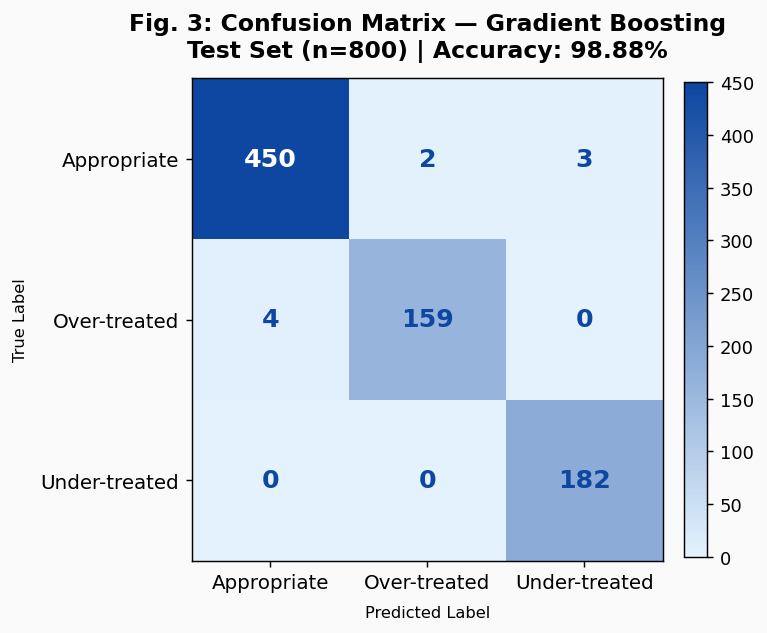

In [13]:
# FIGURE 3 — CONFUSION MATRIX
cm = confusion_matrix(y_test, best_preds)
cmap = LinearSegmentedColormap.from_list('blues', ['#E3F2FD','#0D47A1'])
fig3, ax3 = plt.subplots(figsize=(6,5))
fig3.patch.set_facecolor('#FAFAFA')
im = ax3.imshow(cm, interpolation='nearest', cmap=cmap, aspect='auto')
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
ticks = np.arange(len(classes))
ax3.set_xticks(ticks); ax3.set_xticklabels(classes, fontsize=11)
ax3.set_yticks(ticks); ax3.set_yticklabels(classes, fontsize=11)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14, fontweight='bold', color='white' if cm[i,j]>thresh else '#0D47A1')
ax3.set_xlabel('Predicted Label', fontsize=9, labelpad=7)
ax3.set_ylabel('True Label', fontsize=9, labelpad=7)
ax3.set_title('Fig. 3: Confusion Matrix — Gradient Boosting\nTest Set (n=800) | Accuracy: 98.88%', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figure3_confusion_matrix.png', dpi=130, bbox_inches='tight')
from IPython.display import Image
Image(filename='/content/figure3_confusion_matrix.png')

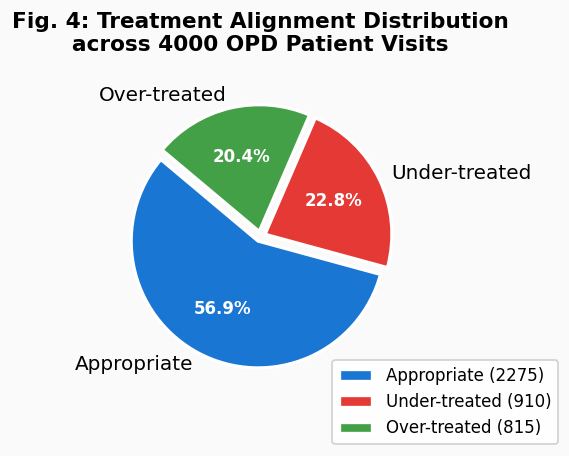

In [14]:
# FIGURE 4 — PIE CHART
align_counts = df['alignment'].value_counts()
fig4, ax4 = plt.subplots(figsize=(6,4))
fig4.patch.set_facecolor('#FAFAFA')
wedges, texts, autotexts = ax4.pie(align_counts.values, labels=align_counts.index, autopct='%1.1f%%', startangle=140, colors=['#1976D2','#E53935','#43A047'], explode=[0.04]*3, wedgeprops=dict(edgecolor='white', linewidth=2), textprops=dict(fontsize=12))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax4.legend(wedges, [f'{l} ({c})' for l,c in zip(align_counts.index, align_counts.values)], loc='lower left', bbox_to_anchor=(0.7,-0.18), fontsize=10, framealpha=0.9)
ax4.set_title('Fig. 4: Treatment Alignment Distribution\nacross 4000 OPD Patient Visits', fontsize=13, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('figure4_pie_alignment.png', dpi=120, bbox_inches='tight')
from IPython.display import Image
Image(filename='/content/figure4_pie_alignment.png')

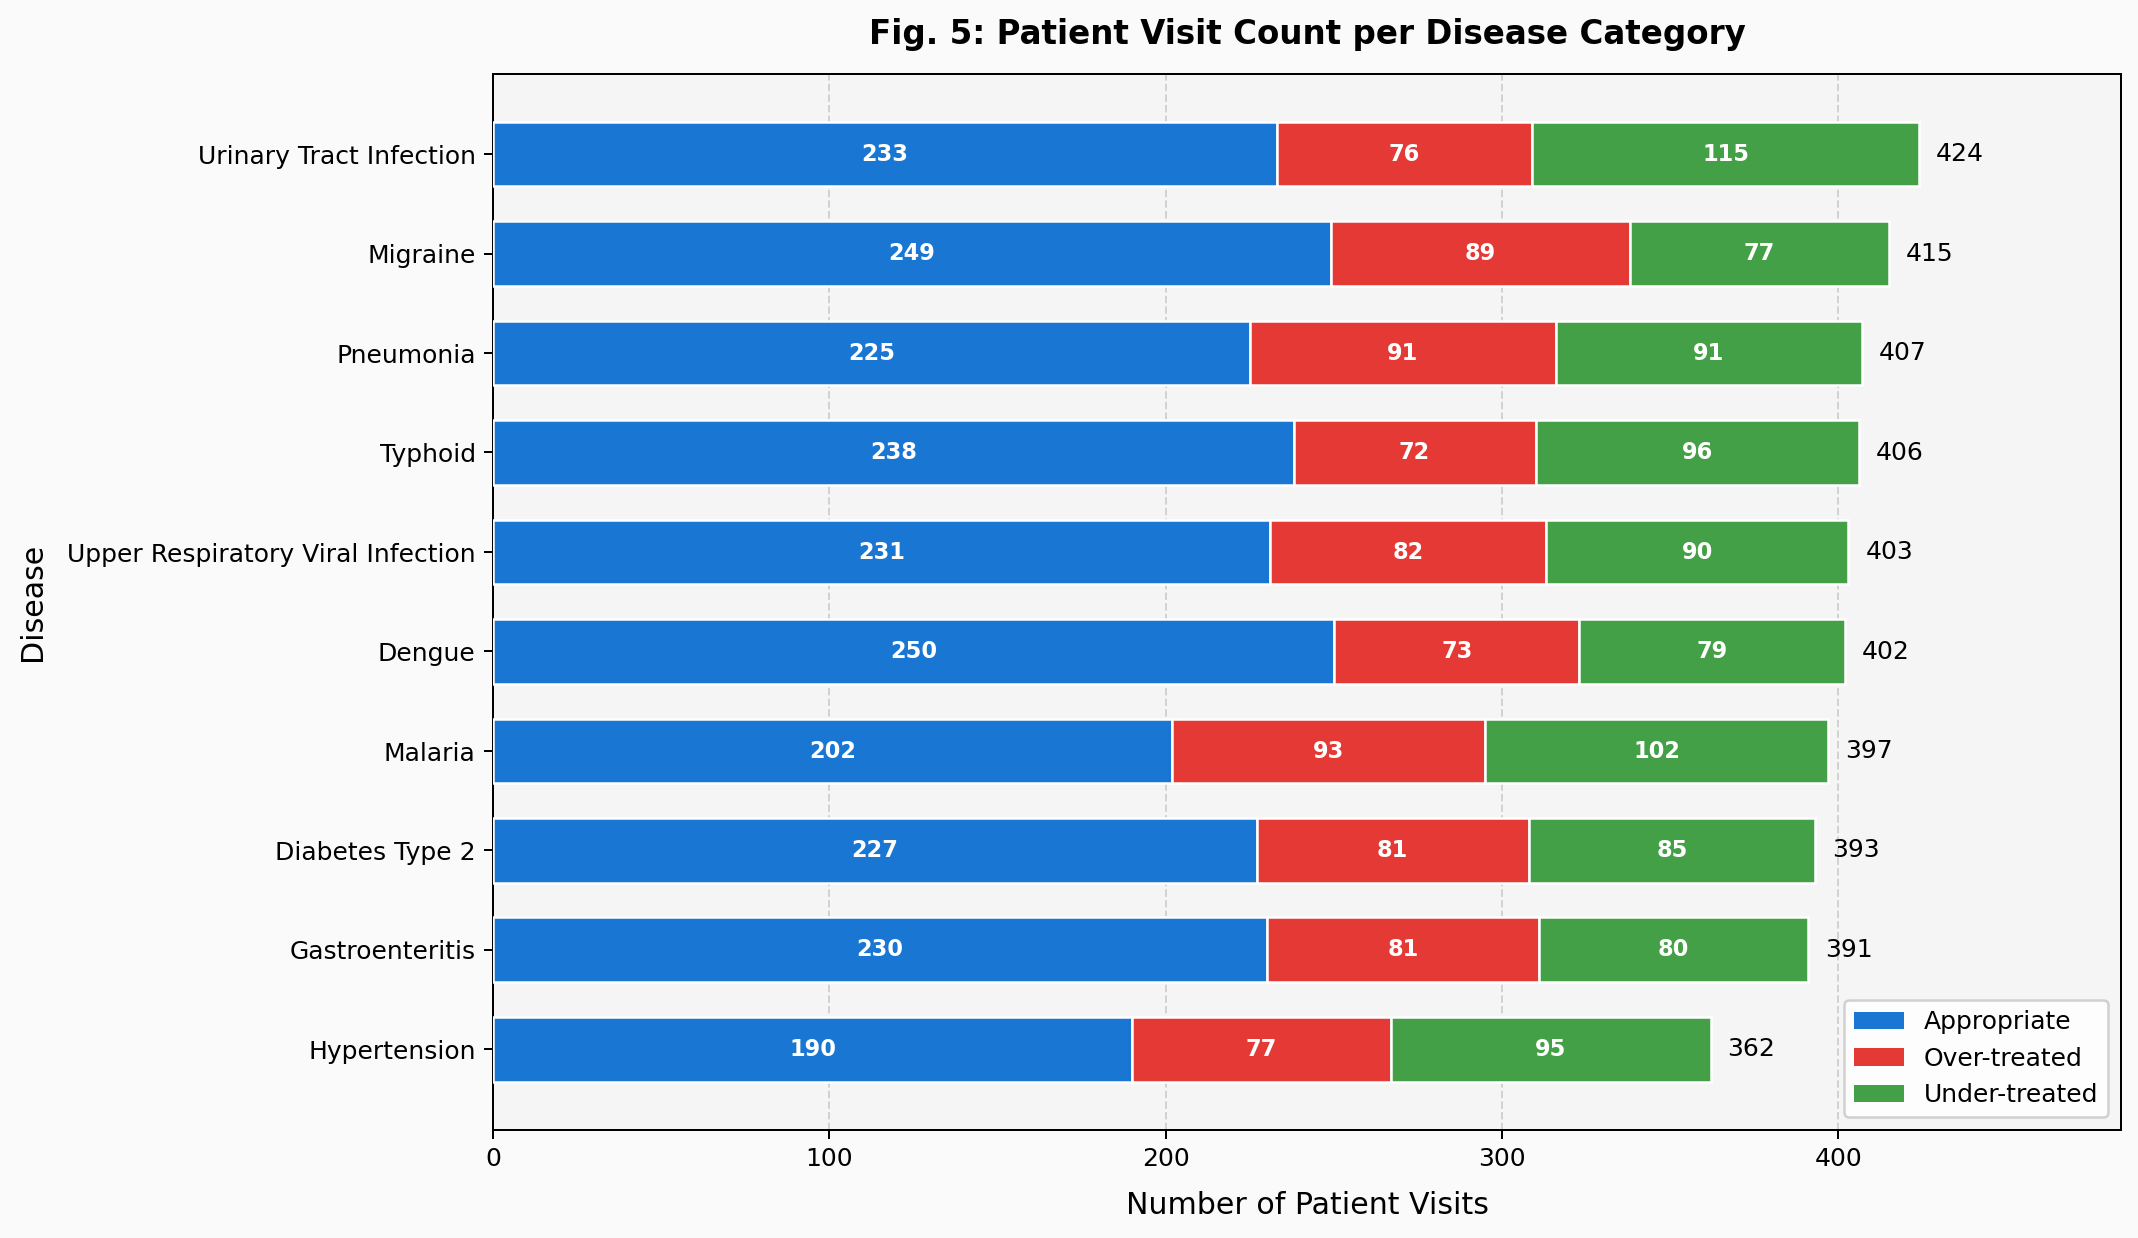

In [15]:
d_counts = df['disease'].value_counts().sort_values(ascending=True)

# ✅ EDIT: replaced d_top & bar_clrs with pivot to capture all 3 alignments
pivot = df.groupby(['disease','alignment']).size().unstack(fill_value=0)
pivot = pivot[['Appropriate','Over-treated','Under-treated']].loc[d_counts.index]

fig5, ax5 = plt.subplots(figsize=(12,7))
fig5.patch.set_facecolor('#FAFAFA'); ax5.set_facecolor('#F5F5F5')

# ✅ EDIT: loop over all 3 categories with left= for stacking
lefts = np.zeros(len(pivot))
for cat, clr in zip(['Appropriate','Over-treated','Under-treated'], ['#1976D2','#E53935','#43A047']):
    vals = pivot[cat].values
    bars = ax5.barh(pivot.index, vals, left=lefts, color=clr, edgecolor='white', height=0.65, label=cat, zorder=3)
    for bar, l in zip(bars, lefts):
        if bar.get_width() > 5:
            ax5.text(l+bar.get_width()/2, bar.get_y()+bar.get_height()/2, str(int(bar.get_width())), va='center', ha='center', fontsize=9, color='white', fontweight='bold')
    lefts += vals

# ✅ EDIT: total count label at end of each full bar
for i, total in enumerate(pivot.sum(axis=1)):
    ax5.text(total+5, i, str(int(total)), va='center', ha='left', fontsize=10)

ax5.set_xlabel('Number of Patient Visits', fontsize=12, labelpad=8)
ax5.set_ylabel('Disease', fontsize=12, labelpad=8)
ax5.set_title('Fig. 5: Patient Visit Count per Disease Category', fontsize=13, fontweight='bold', pad=12)
ax5.set_xlim(0, d_counts.max()+60)
ax5.grid(True, axis='x', linestyle='--', alpha=0.5, zorder=0)
ax5.legend(handles=[mpatches.Patch(facecolor=c, label=l) for c,l in zip(['#1976D2','#E53935','#43A047'], ['Appropriate','Over-treated','Under-treated'])], loc='lower right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig('figure5_bar_disease_count.png', dpi=180, bbox_inches='tight')
from IPython.display import Image
Image(filename='/content/figure5_bar_disease_count.png')


In [16]:
# SECTION 15: FINAL SUMMARY
print("\n" + "="*50)
print("   FINAL RESULTS SUMMARY")
print("="*50)
for name, r in results.items():
    print(f"  {name:<22} Acc: {r['acc']}%  F1: {r['f1']}%")
print("="*50)
print("  Best Model : Gradient Boosting — 98.88%")
print("  Figures    : 5 saved as PNG (180 DPI)")
print("  Dataset    : alignment_results_final.csv")
print("="*50)



   FINAL RESULTS SUMMARY
  Logistic Regression    Acc: 86.88%  F1: 86.87%
  Random Forest          Acc: 92.88%  F1: 92.85%
  Gradient Boosting      Acc: 98.88%  F1: 98.87%
  Linear SVM             Acc: 86.88%  F1: 86.86%
  Best Model : Gradient Boosting — 98.88%
  Figures    : 5 saved as PNG (180 DPI)
  Dataset    : alignment_results_final.csv
